### Hello! This is an Attempt to do Audio Analysis of MP3 file. 
First we explore the correct library and then we find out the tempo of the audio. As a non-experienced audio person I did my research and found out that Librosa is a reliable library supported by many to perform basic tasks in Python for audio analysis. So lets import the libraries. The notebook is into two parts according to the task given. First is the visualization of audio to track beats in terms of time and estimate the overall tempo. Second part is the bonus part which contains in depth analysis of the music file through various methods. If I have to divide the audio analysis into parts I would divide it into three parts
- High Level Abstraction(**Instrumentation, Key Chords, Melody, Rhythm, Tempo, Lyrics**)
- Mid Level Abstraction(**Pitch and Beat-Related Descriptors, such as note onsets, fluctuation patterns and MFCCs**)
- Low Level Abstraction(**Spectral Flux, Energy, Spectral Centroid, Zero Cross Rate etc**)

We will be doing the analysis in this direction-

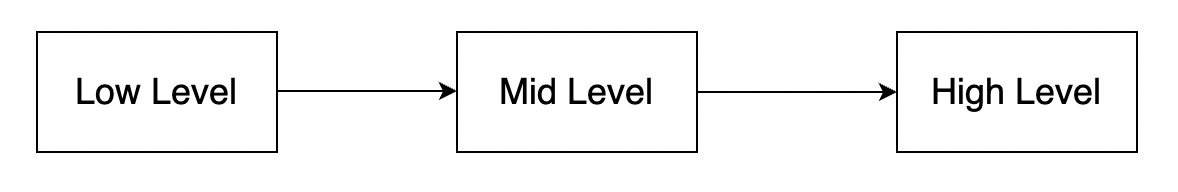

In [83]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

#### Loading and extracting waveforms.
Here y receives the audio as a **waveform** and sr is **Sample Rate** which basically is nothing but in simple language how many snapshots of sound we take in a second. After doing some research I found out that 44,100 Hz is usually good enough for standard CD quality audio.

In [84]:
file_path = "loudly.mp3"
y, sr = librosa.load(file_path, sr=None)  
duration = librosa.get_duration(y=y, sr=sr)

In [85]:
print(y)
print(sr)
print(duration)

[-1.7786724e-04 -2.2421876e-04 -2.2738444e-04 ... -1.7288176e-06
 -2.0032608e-06  5.2458188e-07]
44100
24.006802721088434


#### Let's listen to the audio!

In [86]:
import IPython.display as ipd
ipd.Audio(file_path)

#### Observation-
After listening to it I can recognize the different instruments being played. The **rhythm** of the audio sounds to be **regular** which is good. **Groovy, Lofi music**. It has bass, drums and piano like sound but I am not able to exactly classify it. Let's try to extract **harmonic component**(vocals and instruments) from **percussive component**(drums)

Text(0.5, 1.0, 'Harmonic + Percussive')

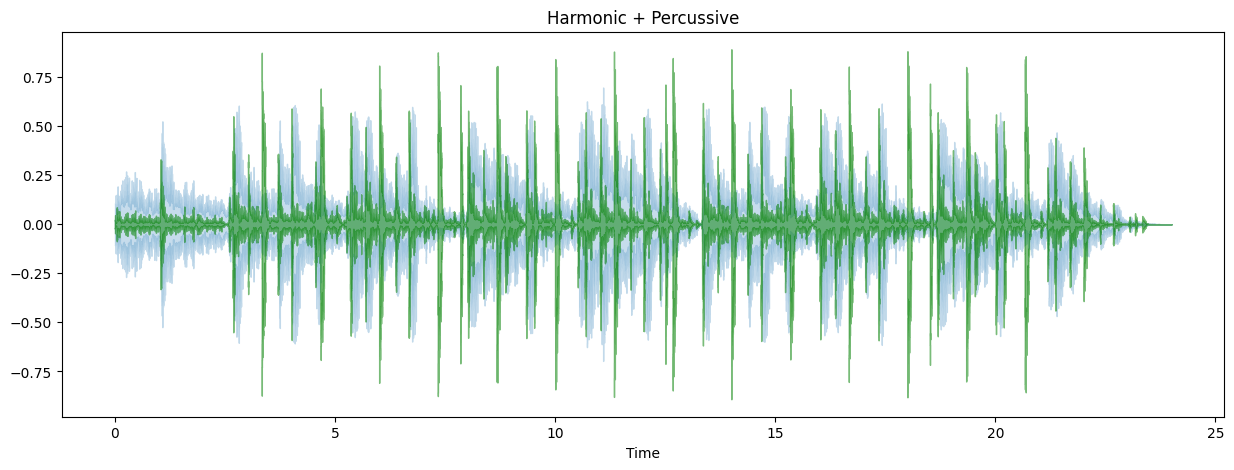

In [89]:
y_harmonic, y_percussive = librosa.effects.hpss(y)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(y_harmonic, sr=sr, alpha=0.25)
librosa.display.waveshow(y_percussive, sr=sr, color='g', alpha=0.5)
plt.title('Harmonic + Percussive')

#### Beat Extraction

In [90]:
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)

#### Convert Beat Frames to Time

In [91]:
beat_times = librosa.frames_to_time(beat_frames, sr=sr)

### Print the Estimated Tempo and Beat Positions

In [92]:
print(f"Tempo of the music: {tempo[0]:.2f} BPM")
print(f"The position in time of each beat in the given piece of audio (seconds): {beat_times}")

Tempo of the music: 90.67 BPM
The position in time of each beat in the given piece of audio (seconds): [ 3.35528345  4.02866213  4.67882086  5.36380952  6.01396825  6.68734694
  7.34911565  8.02249433  8.68426304  9.35764172 10.01941043 10.69278912
 11.35455782 12.01632653 12.67809524 13.35147392 14.01324263 14.68662132
 15.34839002 16.02176871 16.68353741 17.3569161  18.01868481 18.69206349
 19.3538322  20.02721088 20.67736961 21.36235828 22.02412698 22.68589569]


#### Let's visualize the audio waveform and mark the beat positions on the time axis.

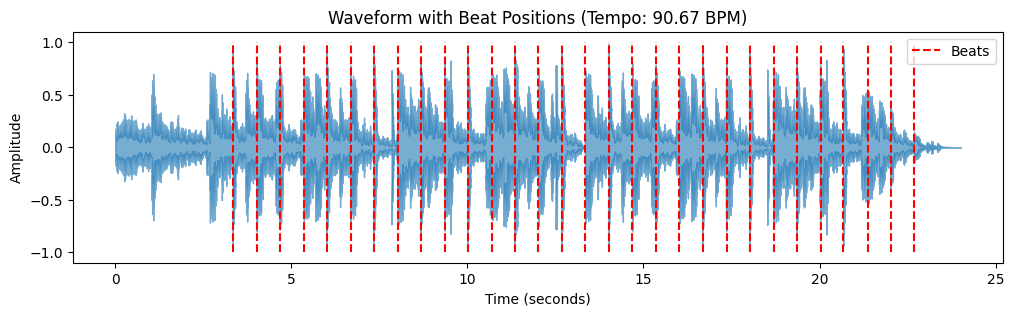

In [93]:
plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr, alpha=0.6)
plt.vlines(beat_times, ymin=-1, ymax=1, color='r', linestyle='--', label="Beats")
plt.title(f"Waveform with Beat Positions (Tempo: {tempo[0]:.2f} BPM)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

#### Let's try to make it more clear

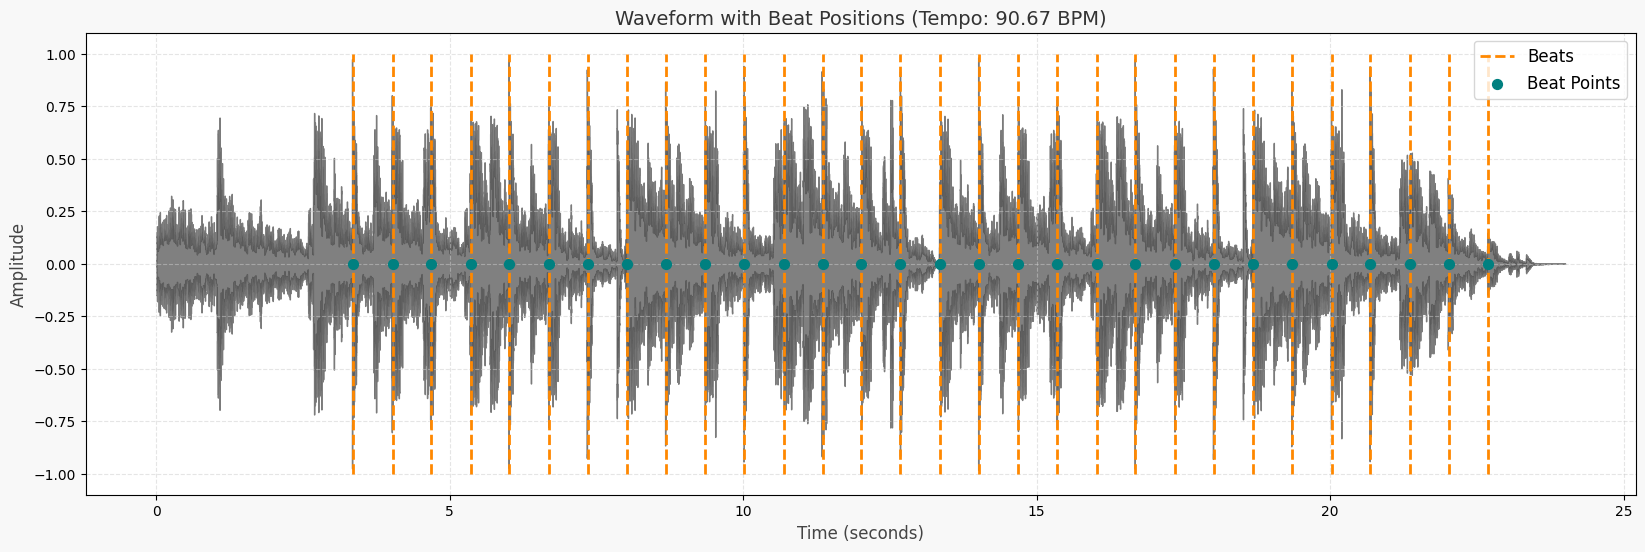

In [94]:
plt.figure(figsize=(20, 6), facecolor="#f8f8f8")

librosa.display.waveshow(y, sr=sr, alpha=0.7, color='#4a4a4a')

plt.vlines(beat_times, ymin=-1, ymax=1, color='#ff8800', linestyle='--', linewidth=2, label="Beats")

plt.scatter(beat_times, np.zeros_like(beat_times), color='#008080', s=50, label="Beat Points", zorder=3)

plt.title(f"Waveform with Beat Positions (Tempo: {tempo[0]:.2f} BPM)", fontsize=14, color="#333333")
plt.xlabel("Time (seconds)", fontsize=12, color="#444444")
plt.ylabel("Amplitude", fontsize=12, color="#444444")
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", color="#cccccc", alpha=0.5)
plt.show()

#### Plot the beats more clearly on a separate subplot

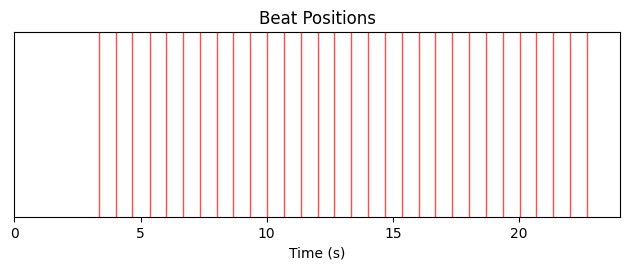

In [95]:
plt.subplot(2, 1, 2)
plt.title("Beat Positions")
plt.xlabel("Time (s)")

for beat_time in beat_times:
    plt.axvline(x=beat_time, color='r', alpha=0.7, linewidth=1)

plt.xlim(0, duration)
plt.yticks([])

plt.tight_layout()
plt.show()

### First Part Conclusion-
- Overall Tempo- 90.67
- Position of Beats as per time axis-  [3.35528345  4.02866213  4.67882086  5.36380952  6.01396825  6.68734694
  7.34911565  8.02249433  8.68426304  9.35764172 10.01941043 10.69278912
 11.35455782 12.01632653 12.67809524 13.35147392 14.01324263 14.68662132
 15.34839002 16.02176871 16.68353741 17.3569161  18.01868481 18.69206349
 19.3538322  20.02721088 20.67736961 21.36235828 22.02412698 22.68589569]

### Additional Feature Extractions(Second Part)-

#### Frequency Over time
Till now we have seen waveforms show amplitude over time. Let's also try to observe frequency over time using spectogram. For this we can use Fourier Transform.

In [136]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

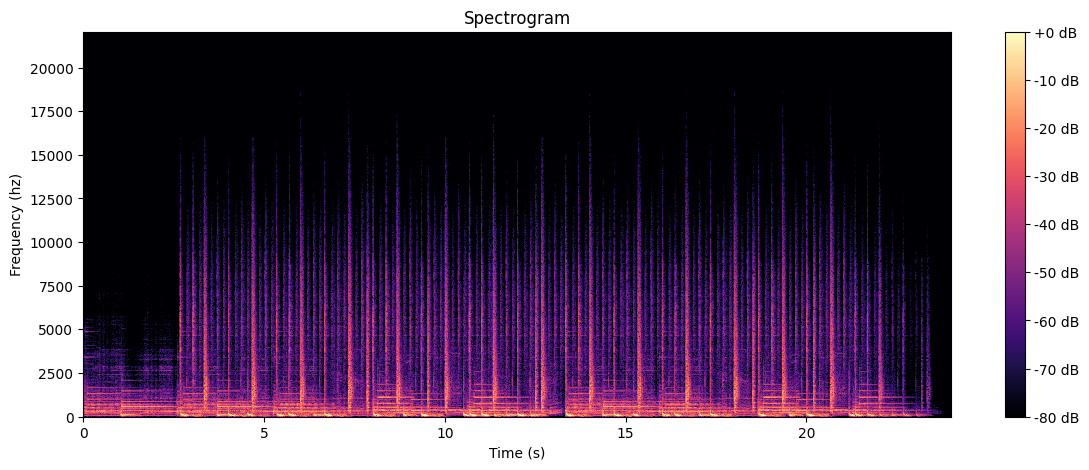

In [137]:
# Display the spectrogram
plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (hz)")
plt.show()

### Spectrogram Analysis Observation-
- **Strong rhythmic structure**: Clear, evenly spaced vertical lines appear consistently throughout the duration, indicating a steady and well-defined beat pattern.  
- **Prominent bass content**: High energy concentration (**bright orange/red**) in the lower frequency range (0-500 Hz) demonstrates a solid bass foundation.  
- **Full frequency spectrum**: Energy distributed across low, mid, and high frequencies suggests a well-balanced mix.  
- **Consistent percussive elements**: Vertical energy spikes extending to high frequencies (up to 20,000 Hz) represent sharp percussive sounds like hi-hats or snares.  
- **Steady Rhythm pattern maintenance**: The rhythmic pattern maintains its regularity across the entire track with minimal variation.  


### Mel Spectogram
#### Why should we also generate Mel Spectogram? As it emphasizes frequencies in a way that better matches human auditory perception. While regular spectogram is a more physically accurate representation.

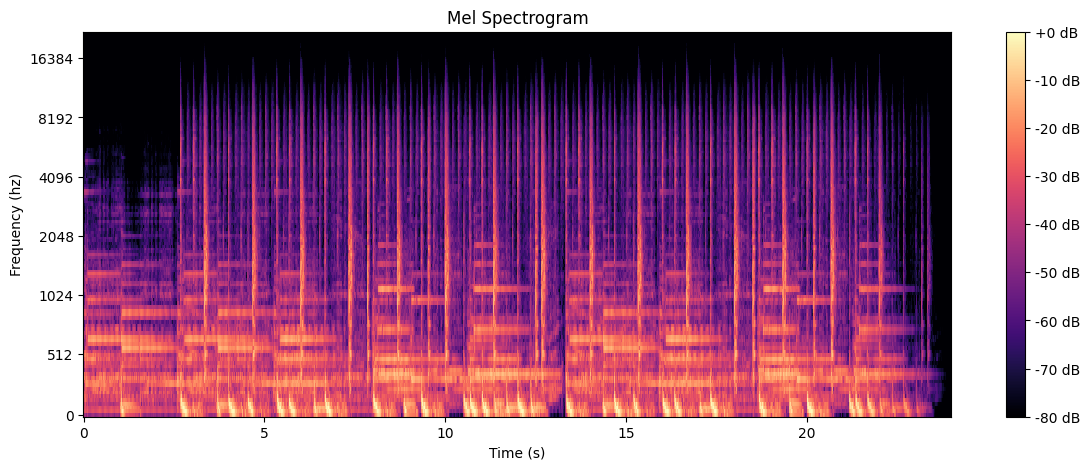

In [116]:
# Compute the mel spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_db_mel = librosa.power_to_db(S, ref=np.max)

# Display the mel spectrogram
plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db_mel, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (hz)")
plt.show()

### Mel Spectogram Observation:
- **Pattern Repitition**: Pattern repeats almost every ~5 seconds, suggesting looping audio.
- **Energy**: concentrated below 1024 Hz (speech/instruments).
- **Vertical**: lines indicate transient sounds (percussive hits/consonants).
- **Harmonic**: content up to 8000 Hz shows fundamental frequency bands.
- **Low frequency**: content (<200 Hz) suggests bass elements.
- **Consistent pattern**: indicates structured audio, not random noise.

Definitely a musical piece with regular rhythm!

### Capturing Temporal Characteristics of Audio Signals
#### Time Domain Features
There are mainly two important time domain features: **Root Mean Square (RMS) Energy** and **Zero Crossing Rate (ZCR)**.

In [134]:
# Calculate RMS energy
frame_length = 2048
hop_length = 512
rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)
rms

array([[4.4334795e-02, 5.0447028e-02, 6.4486668e-02, ..., 1.8847501e-05,
        1.7372397e-05, 1.4807842e-05]], dtype=float32)

In [135]:
# Calculate Zero Crossing Rate
zcr = librosa.feature.zero_crossing_rate(y, frame_length=frame_length, hop_length=hop_length)
zcr

array([[0.01367188, 0.02246094, 0.02929688, ..., 0.16699219, 0.17041016,
        0.13525391]])

#### Combining RMS Energy and Zero Crossing Rate

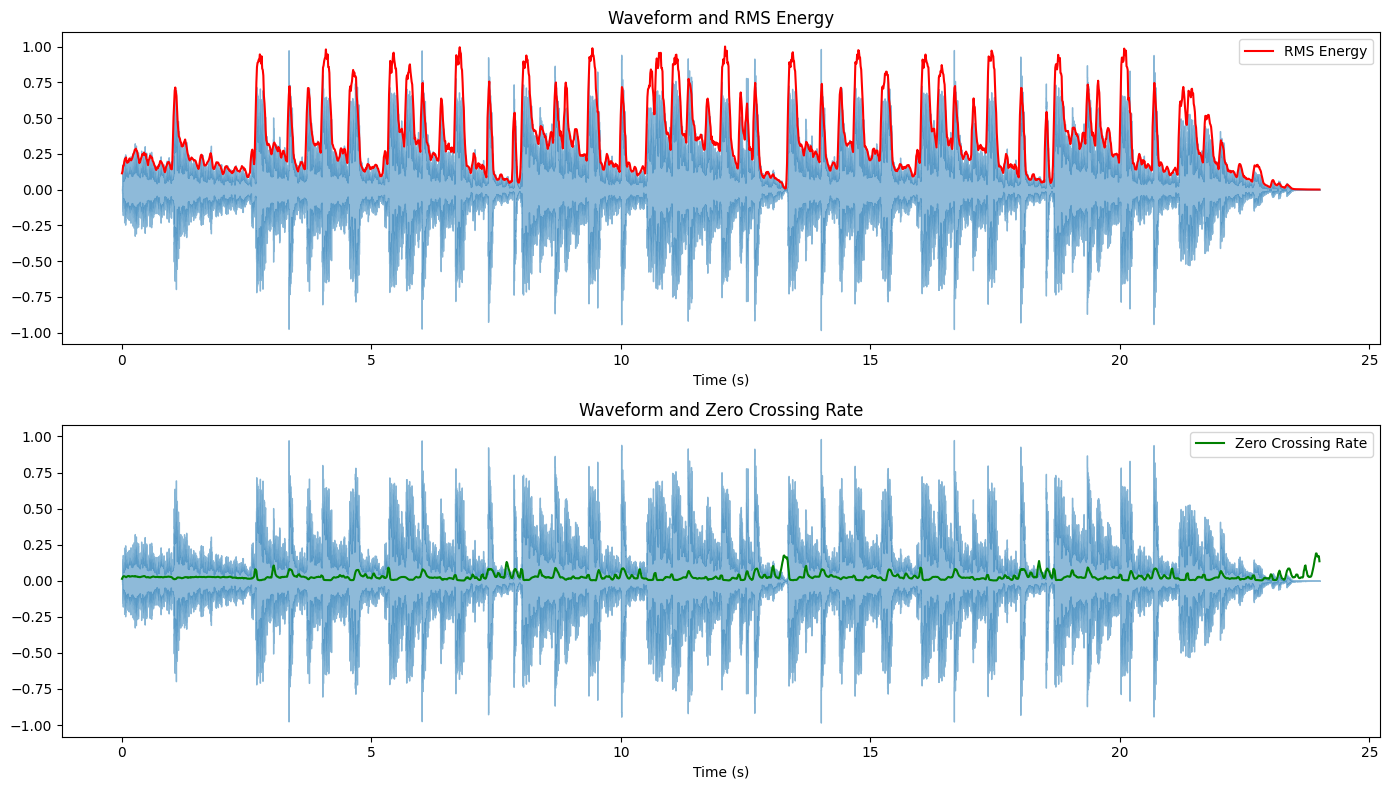

In [120]:
times = librosa.times_like(zcr, sr=sr, hop_length=hop_length)

plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr, alpha=0.5)
plt.plot(times, rms[0] / rms.max(), color='r', label='RMS Energy')
plt.title("Waveform and RMS Energy")
plt.xlabel('Time (s)')
plt.legend()

plt.subplot(2, 1, 2)
librosa.display.waveshow(y, sr=sr, alpha=0.5)
plt.plot(times, zcr[0], color='g', label='Zero Crossing Rate')
plt.title("Waveform and Zero Crossing Rate")
plt.xlabel('Time (s)')
plt.legend()

plt.tight_layout()
plt.show()

### Combined Observations  

- It's very evident that it's a **rhythmic music piece** with regular beats and consistent frequency content.  
- The **low Zero Crossing Rate (ZCR)** suggests the audio is primarily **tonal rather than noisy**.  
- The **Root Mean Square (RMS) energy** confirms the **regular pattern** seen in the spectrogram's vertical lines.  
- The recording has a **clear structure** with consistent intensity throughout, after the **quiet introduction**.

#### Final Temporal Characteristics Result-  The temporal characteristics reveal a structured, rhythmic piece with regular energy patterns and consistent tonal qualities throughout most of its duration.

### More low-level features 
There are more things that we can do for example **frequency domain features**. We saw earlier two spectograms which come under frequency domain features but for **music analysis** we can go even deeper. We can add **spectral centroid**, **spectral rolloff**. 
**Spectral Centroid**- Indicates the brightness of the sound. Higher centroid means **brighter, sharper sounds**. 
**Spectral Rolloff**- Distinguishes between **harmonal and non-harmonal sound**. Higher Rolloff- **Higher Frequency**. Lower Rolloff- **Smoother, bass-dominant sound**.

In [121]:
centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length)

In [122]:
rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=hop_length)

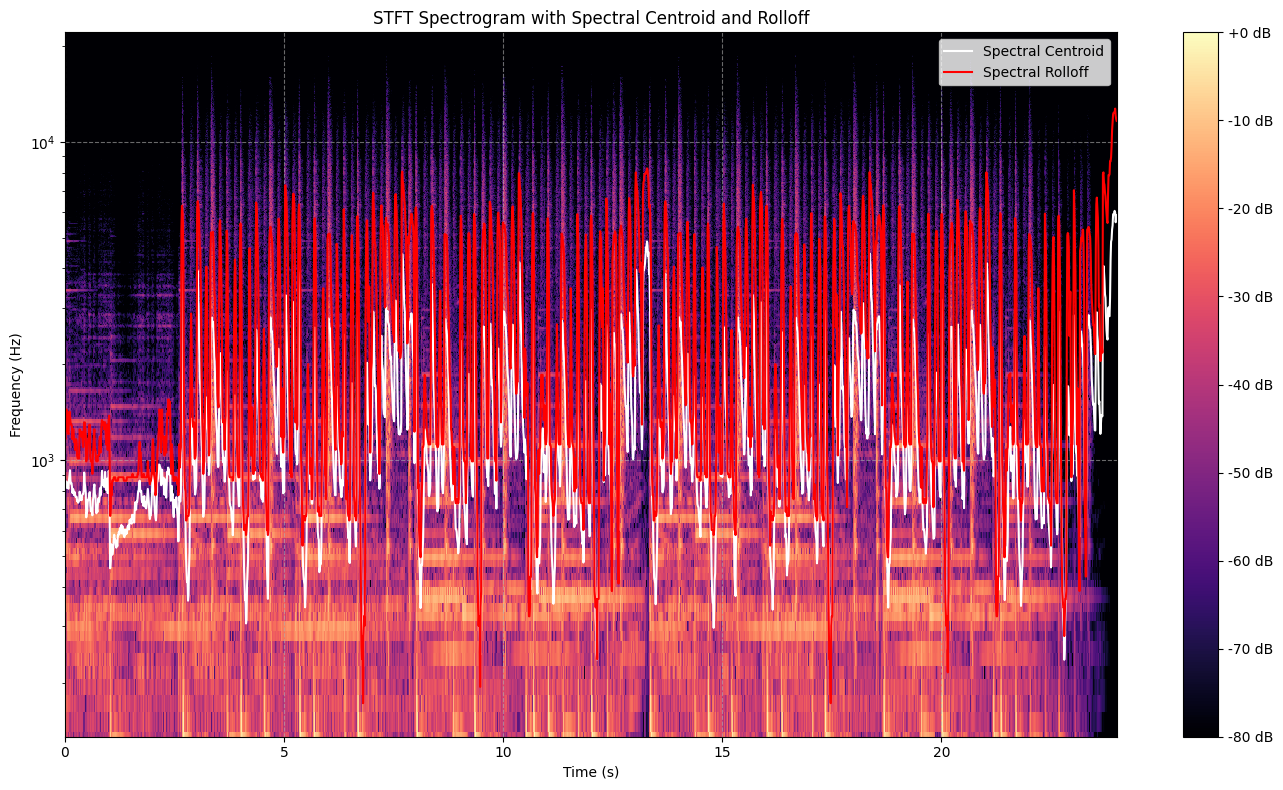

In [124]:
plt.figure(figsize=(14, 8))
times = librosa.times_like(centroid, sr=sr, hop_length=hop_length)
# Plot spectrogram
librosa.display.specshow(D_db, sr=sr, x_axis='time', y_axis='log', hop_length=hop_length)
plt.colorbar(format='%+2.0f dB')
plt.title('STFT Spectrogram with Spectral Centroid and Rolloff')

# Plot spectral centroid on top of the spectrogram
plt.semilogy(times, centroid[0], label='Spectral Centroid', color='w')

# Plot spectral rolloff on top of the spectrogram
plt.semilogy(times, rolloff[0], label='Spectral Rolloff', color='r')

plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Observations-
- As mentioned earlier this audio likely has a strong **rhythmic structure** with **clear transients**.
- **High energy** in **lower spectrum** suggests that the bass is prominent, providing a solid foundation. It could belong to **electronic music, pop, or hip-hop** with **consistent beats**.
- The values of **spectral centroid** and **rolloff** indicate a balanced mix with both low and high frequencies contributing.

### Mid Level Features- MFCCs are useful in Music Genre Classification

In [105]:
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

Text(0.5, 0, 'Time (s)')

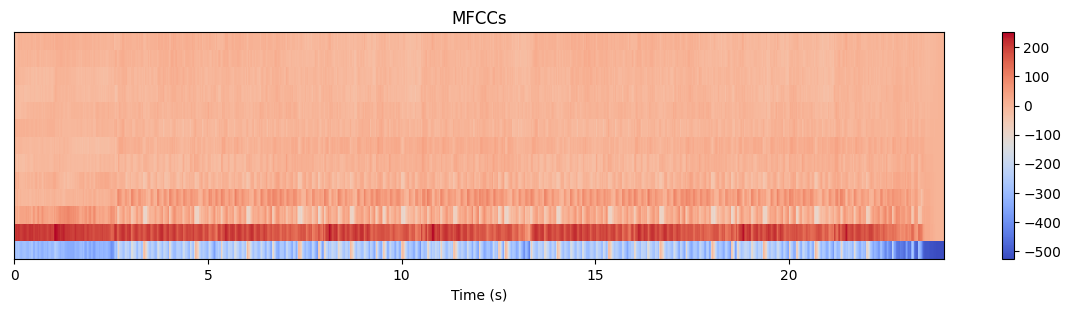

In [126]:
plt.figure(figsize=(15, 10))
# MFCCs
plt.subplot(3, 1, 2)
librosa.display.specshow(mfccs, x_axis="time", sr=sr)
plt.colorbar()
plt.title("MFCCs")
plt.xlabel("Time (s)")

### Observations

- The audio appears to have a **strong low-frequency presence** (due to the dominance of lower MFCCs in red).  
- The consistency of the colors across time suggests a **steady, rhythmic sound** rather than highly dynamic changes.  
- It could indicate a track with a **strong beat and low-end emphasis**, possibly in genres like **electronic music, hip-hop, or pop**.  

### High level Analysis- Key, Chords, Melody, Rhythm, Tempo, Lyrics, Genre, Mood
Spectral Chroma is helpful in identifying the intensity of different class pitches(A,C#,B etc). Its very helpful in **pitch classification**.

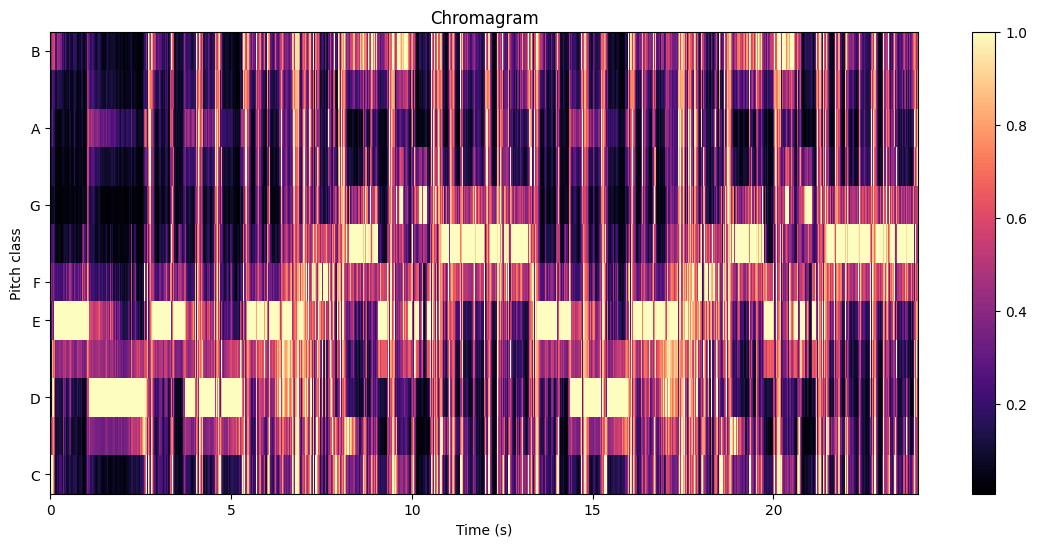

In [127]:
chroma = librosa.feature.chroma_stft(y=y, sr=sr)
plt.figure(figsize=(14, 6))
librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma')
plt.colorbar()
plt.title('Chromagram')
plt.xlabel('Time (s)')
plt.show()

#### The chromagram shows the intensity of different pitch classes over time, indicating a varied harmonic structure with prominent melodic patterns. Bright regions(C, D, E) suggest recurring notes or chords(blocks of pitches), common in structured musical genres.

### Let's plot the individual pitch classes

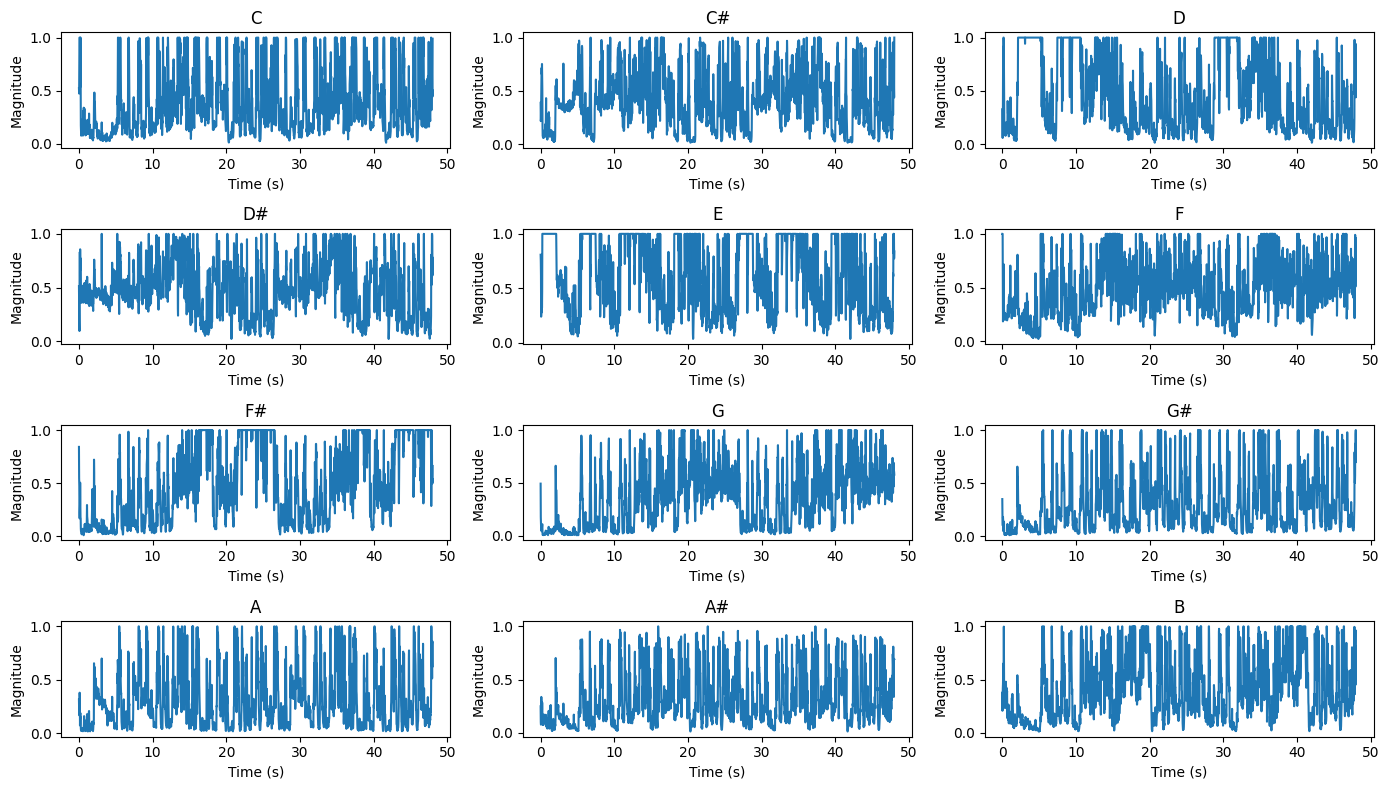

In [130]:
pitch_classes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

plt.figure(figsize=(14, 8))
for i in range(12):
    plt.subplot(4, 3, i+1)
    plt.plot(librosa.times_like(chroma), chroma[i])
    plt.title(pitch_classes[i])
    plt.xlabel('Time (s)')
    plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

#### Energy variation over time of different pitch classes. 
It can be easily done by Chroma Energy Normalized Statistics(CENS)

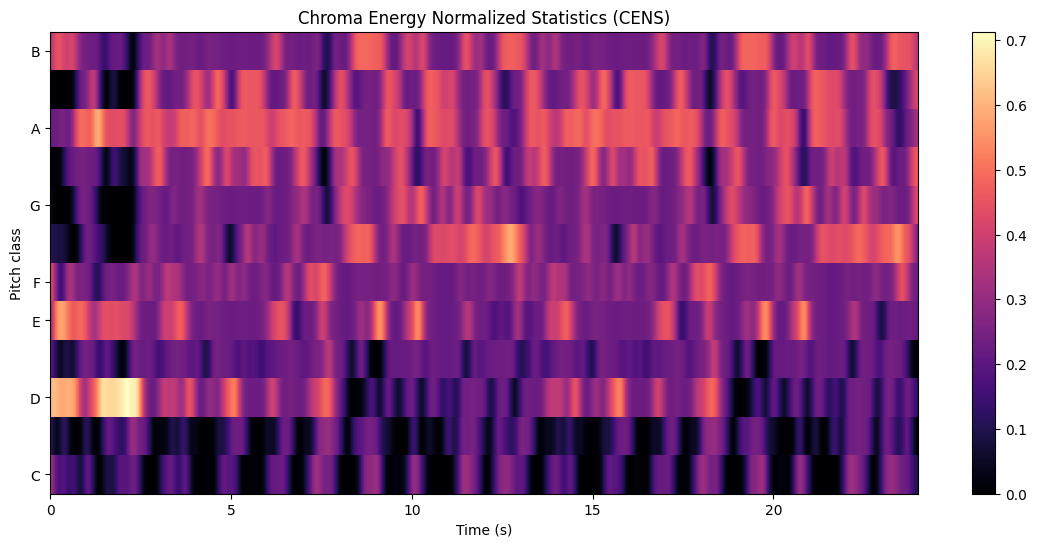

In [131]:
# Compute CENS features
cens = librosa.feature.chroma_cens(y=y, sr=sr)

# Visualize CENS features
plt.figure(figsize=(14, 6))
librosa.display.specshow(cens, sr=sr, x_axis='time', y_axis='chroma')
plt.colorbar()
plt.title('Chroma Energy Normalized Statistics (CENS)')
plt.xlabel('Time (s)')
plt.show()

#### The above plot provides a visual representation of how different pitch classes evolve over time, with varying levels of intensity.
- Pitch **D** goes from bright to dark. 
- Pitch **A** is consistent.

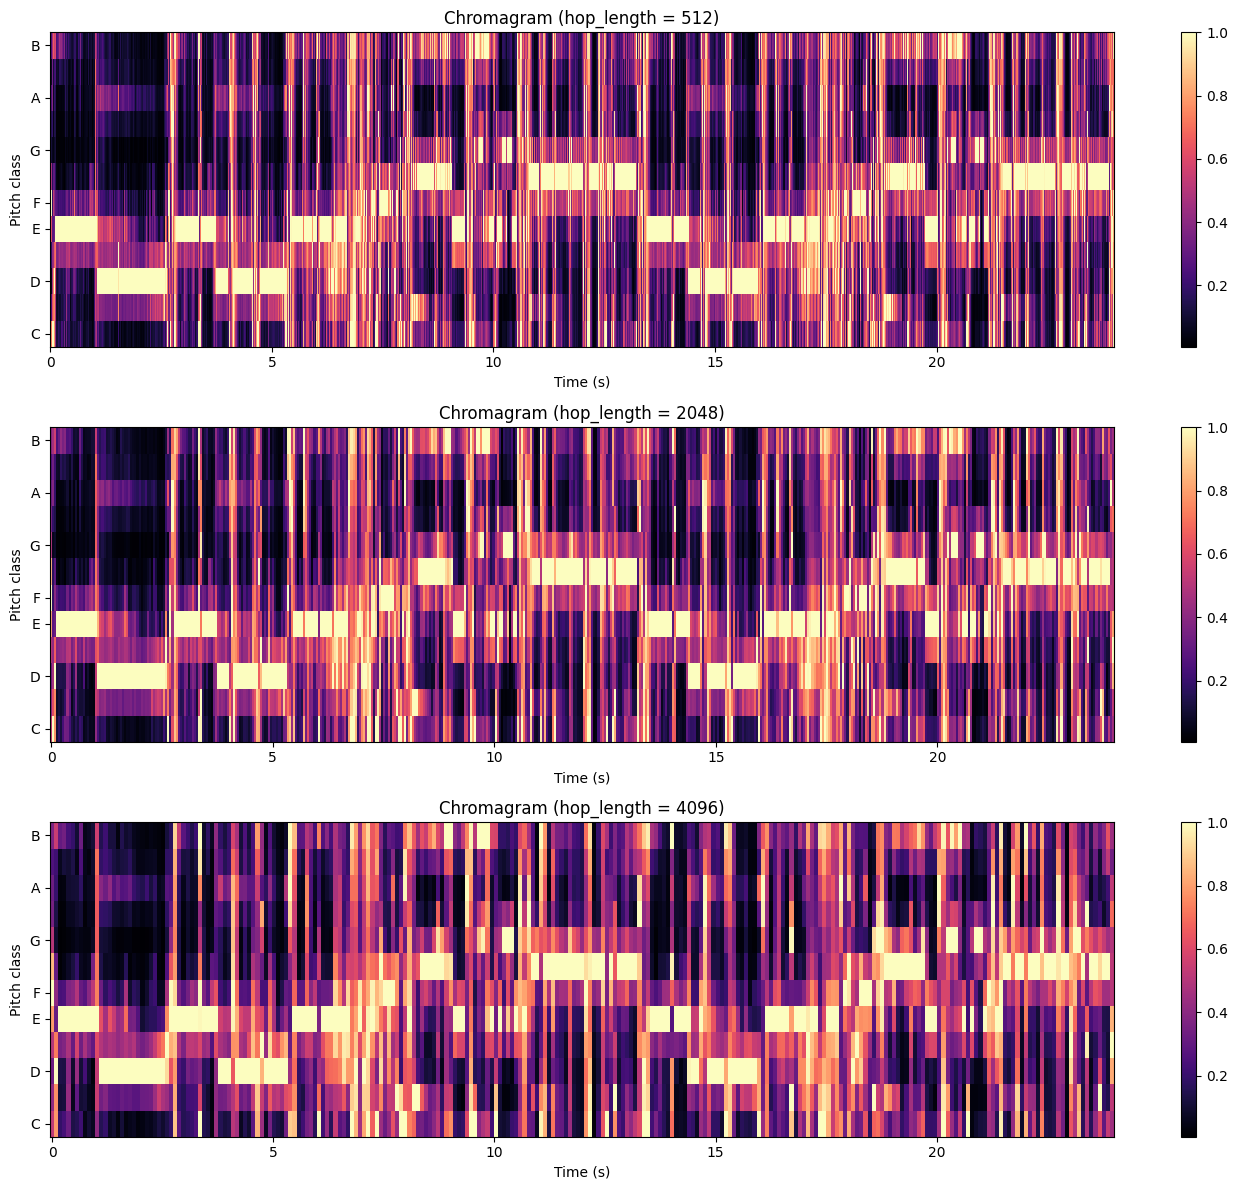

In [132]:
hop_lengths = [512, 2048, 4096]
plt.figure(figsize=(14, 12))

for i, hop_length in enumerate(hop_lengths):
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=hop_length)
    plt.subplot(3, 1, i+1)
    librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', hop_length=hop_length)
    plt.colorbar()
    plt.title(f'Chromagram (hop_length = {hop_length})')
    plt.xlabel('Time (s)')

plt.tight_layout()
plt.show()

#### Observation
As we can see the consistency is maintained across various hop values

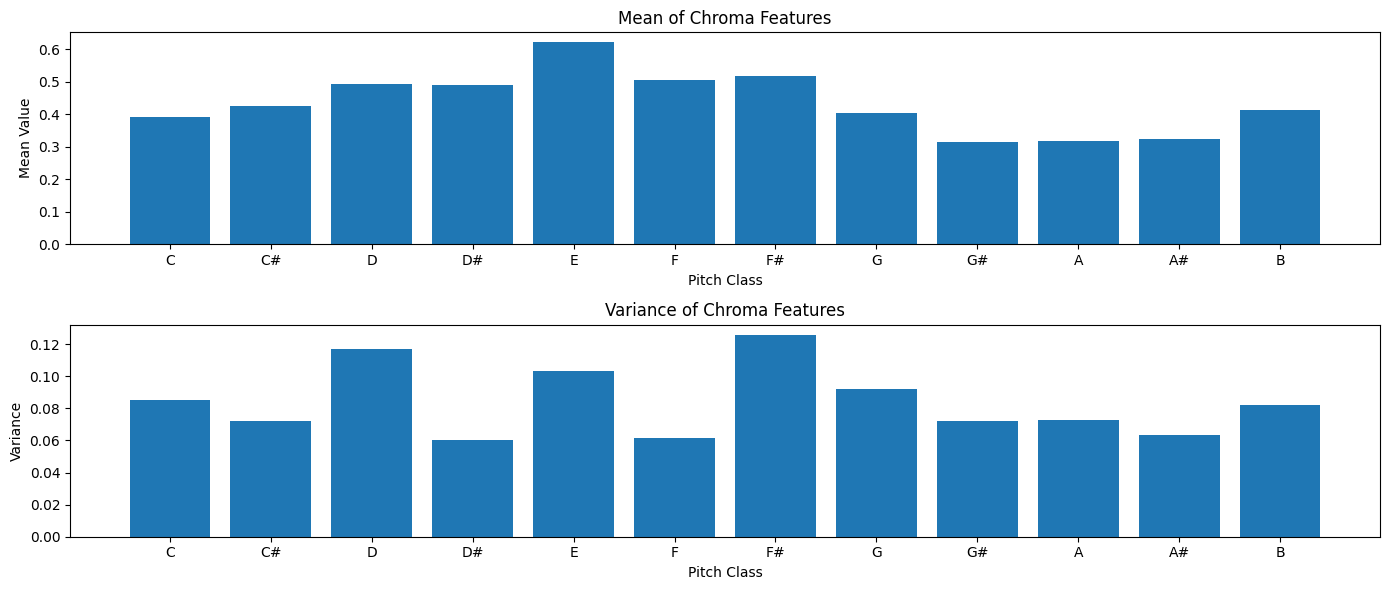

In [133]:
# Calculate statistics
chroma_means = np.mean(chroma, axis=1)
chroma_vars = np.var(chroma, axis=1)

# Display statistics
plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.bar(pitch_classes, chroma_means)
plt.title('Mean of Chroma Features')
plt.xlabel('Pitch Class')
plt.ylabel('Mean Value')

plt.subplot(2, 1, 2)
plt.bar(pitch_classes, chroma_vars)
plt.title('Variance of Chroma Features')
plt.xlabel('Pitch Class')
plt.ylabel('Variance')

plt.tight_layout()
plt.show()

#### Observation
Here we can see that pitch class **E** is most prominent pitch while **F#** has the most variance. Pitch classes like **A#**, **D#**, **F** are more consistent in their chroma features, as indicated by their lower variance.

### Final Conclusion
- The audio file has a tempo of 90.67 BPM.
- Higher energy concentration in lower frquency band shows a solid bass foundation.
- The higher frequencies are also having a pattern and its percussive in nature.
- The rhythmic pattern is very regular.
-  The music is based on the E minor scale, which consists of the notes E, F#, G, A, B, C, and D. It conveys a more somber or melancholic mood compared to major keys.

### Thought Process-
- Firstly I decided the check the file and try to identify by myself what type of music is it. To me it sounds somewhere around Lofi.
- Researching about the library was the next task. Librosa stood out among the others for example Essentia, Madmom etc. It was recommended by ChatGPT, Reddit, YouTube etc according to the use-cases.
- Data Analysis can be simply classified into these steps if we dont go for ML and Deep Learning. Even then we just add more steps but overview remains similar.
[Start] --> [Collect Data] --> [Clean Data] --> [Analyze Data] --> [Generate Report] --> [End]
- Data Collection here was simply extracting the audio data from the file and converting it into waveforms which represents amplitude with respect to time. After some research I learnt that this is how you start the data processing in audio for a lot of the cases.
- For cleaning the data we have to make sure that there is no noise in the audio. Since this audio was very short and clear I did not do this step. Otherwise its better to convert mp3 format to wav format and use libraries like PyDub to clean it and then convert it back for further analysis.
- Here we analyzed the data in various ways first was simple amplitude vs time plots. Then came frequency domain features like Spectral Analysis. After that time domain analysis like Zero Cross Rate. Here definitely frequency domain features had an edge as they were more informative about the features which are precisely related to music for example melody, rhythm, genre, key etc. I have already written my observations after every plot.
- **How did I do verification of my work when I dont really have any knowledge about audio?**
  
    Since I lacked prior expertise in audio analysis, I relied on online tools to validate my findings:
    - Tempo Verification: I used Voice.ai, which estimated the tempo as 90 BPM, while Librosa gave 90.67 BPM—a close match, confirming accuracy.
    - Spectral Analysis: Sonic Visualiser helped me visualize the music file and analyze the spectral plot. The plots I generated were highly similar to those in Sonic Visualiser. Additionally, I could observe real-time changes in the plot as the music progressed, reinforcing my results.
    This cross-validation ensured my analysis was reliable despite my initial lack of audio expertise.

### More feature discussion
Theoritically I would like to go even deeper in the discussion and try to think of the useful characteristics for a musician which the field of ML can provide. 
- **Genre Classification**: ML models like Random Forest and CNNs analyze audio features (MFCCs, chromagrams) to accurately classify music into genres.
- **Melody & Chord Recognition**: HMMs track note sequences, while RNNs/Transformers predict melodies, aiding in composition and transcription.
- **Vocal Separation**: Tools like Spleeter use deep learning to isolate vocals from instrumentals, helping in remixing and karaoke applications.
- **Mood & Emotion Detection**: By analyzing tempo, harmony, and loudness, CNN models predict the mood of a track, useful for playlist curation.